# 4.2: Planes in $\mathbb{R}^3$



Now we shift or focus to the study of planes in three-dimensional Euclidean space. In particular, we want to describe different forms of equations that define a plane in $\mathbb{R}^3$ just like we did for lines. A difference here is that the dot product, especially its geometric interpretation and the criterion for orthogonality, comes in handy here.

## Planes through the origin

Let us again start with planes that go through the origin. Recall that planes can be described as the **span** of two vectors $\vec u$ and $\vec v$, i.e. the collection of all linear combinations of $\vec u$ and $\vec v$. The following picture illustrates an example of a plane spanned by $\vec u$ and $\vec v$, and a vector $\vec r$ on the plane decomposed as $2\vec u + 3\vec v$.

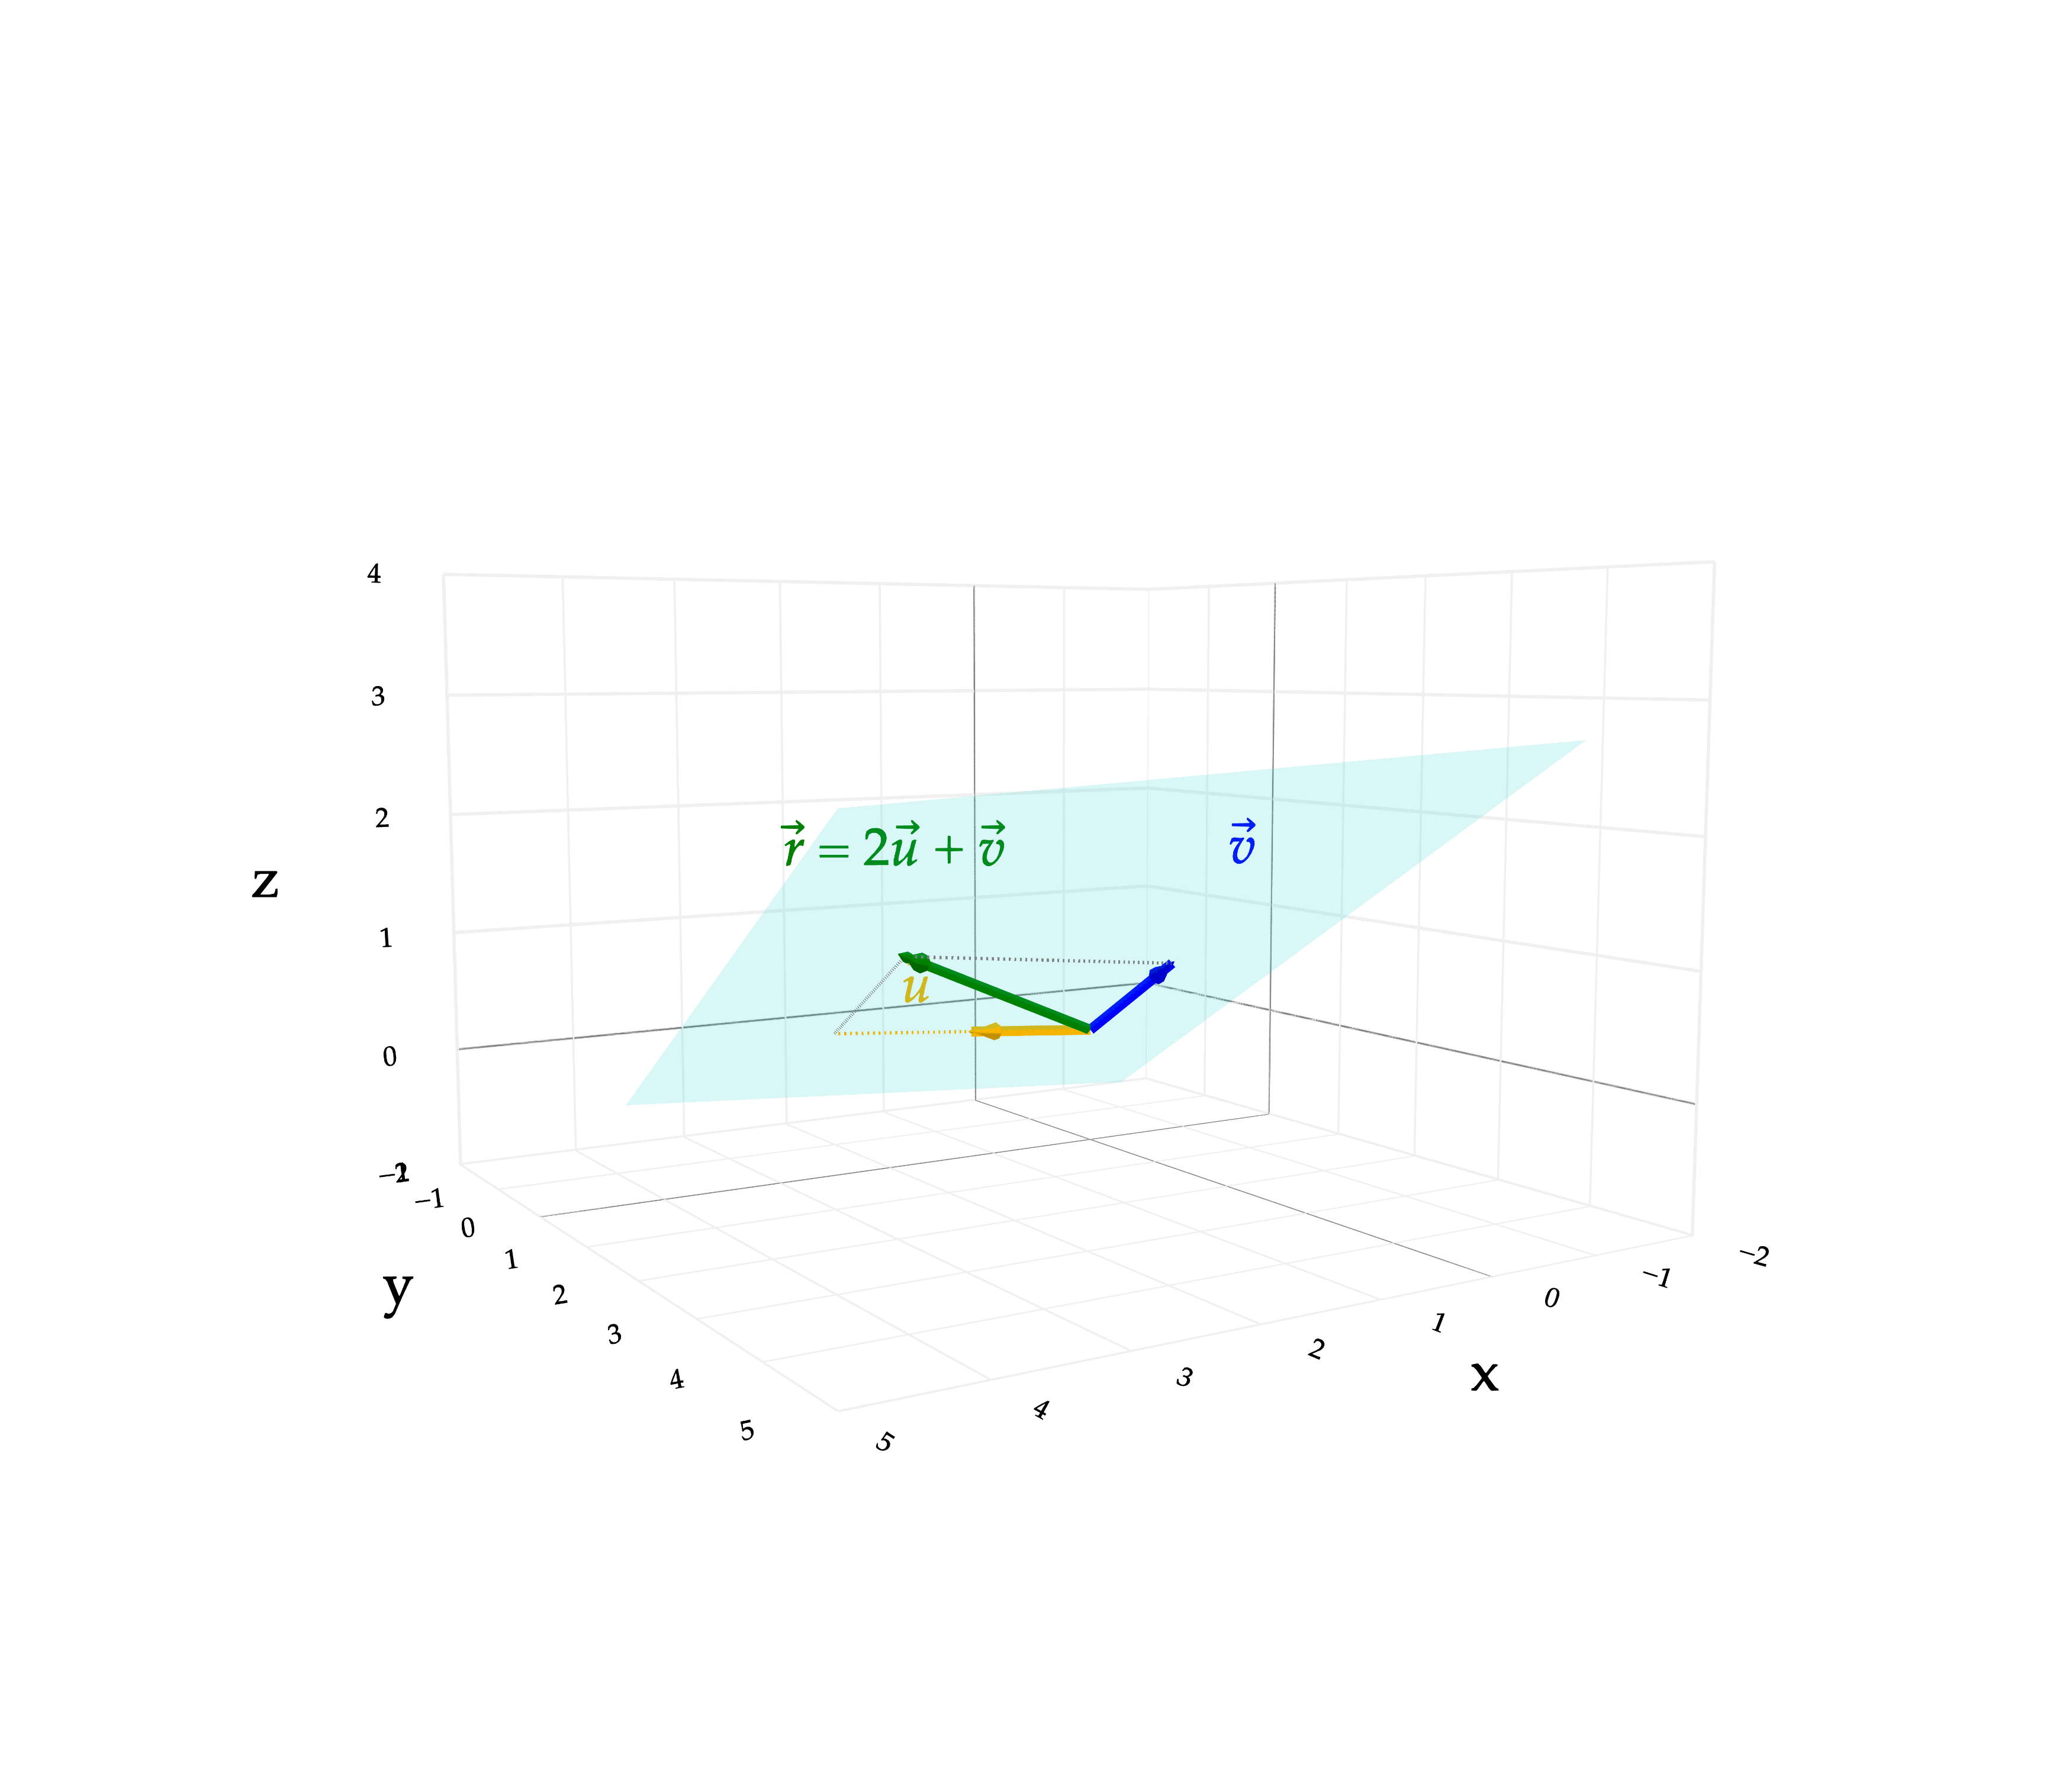

In [9]:
import plotly.io as pio
import plotly.graph_objects as go
import numpy as np

# Set default renderer to high-DPI static image
pio.renderers.default = "png"

# ---
from utils import plot_vectors_non_origin

# Define the coordinates using numpy arrays
O = np.array([0, 0, 0])
u = np.array([1.5, 0.5, 0.2])
v = np.array([0.2, 1.5, 0.8])
r = 2*u + 1*v

# 1. REMOVE AUTOMATIC LABELS & FIX TUPLES
vectors = [
    ((tuple(O), tuple(u)), '#f4b400', ''),                 
    ((tuple(O), tuple(v)), 'blue', ''),                
    ((tuple(O), tuple(r)), 'green', '')                    
]

# Generate the base lines
fig = plot_vectors_non_origin(vectors, vdeltax=0, vdeltay=0, vdeltaz=0)

# 2. ADD THE SPANNED PLANE (Semi-transparent)
c1 = -1*u - 1*v
c2 = 3*u - 1*v
c3 = 3*u + 4*v
c4 = -1*u + 4*v

fig.add_trace(go.Mesh3d(
    x=[c1[0], c2[0], c3[0], c4[0]],
    y=[c1[1], c2[1], c3[1], c4[1]],
    z=[c1[2], c2[2], c3[2], c4[2]],
    i=[0, 0], j=[1, 2], k=[2, 3],
    color='cyan',
    opacity=0.15,
    showscale=False,
    hoverinfo='skip'
))

# 3. ENHANCE ARROWHEADS WITH 3D CONES
def add_cone(fig, start, end, color):
    fig.add_trace(go.Cone(
        x=[end[0]], y=[end[1]], z=[end[2]],
        u=[end[0]-start[0]], v=[end[1]-start[1]], w=[end[2]-start[2]],
        sizemode="absolute", sizeref=0.3, anchor="tip",
        colorscale=[[0, color], [1, color]], showscale=False, hoverinfo='skip'
    ))

add_cone(fig, O, u, '#f4b400')
add_cone(fig, O, v, 'blue')
add_cone(fig, O, r, 'green')

# 4. DRAW THE DECOMPOSITION PARALLELOGRAM
# Dashed line for 2u
fig.add_trace(go.Scatter3d(
    x=[O[0], 2*u[0]], y=[O[1], 2*u[1]], z=[O[2], 2*u[2]],
    mode='lines', line=dict(color='#f4b400', width=2, dash='dash'), hoverinfo='skip', showlegend=False
))
# Closing the parallelogram from 2u to r (parallel to v)
fig.add_trace(go.Scatter3d(
    x=[2*u[0], r[0]], y=[2*u[1], r[1]], z=[2*u[2], r[2]],
    mode='lines', line=dict(color='gray', width=2, dash='dash'), hoverinfo='skip', showlegend=False
))
# Closing the parallelogram from v to r (parallel to 2u)
fig.add_trace(go.Scatter3d(
    x=[v[0], r[0]], y=[v[1], r[1]], z=[v[2], r[2]],
    mode='lines', line=dict(color='gray', width=2, dash='dash'), hoverinfo='skip', showlegend=False
))

# 5. MANUAL LABEL POSITIONING
label_x = [u[0]+0.4, v[0]-0.4, r[0]+0.2]
label_y = [u[1]-0.2, v[1]+0.4, r[1]+0.2]
label_z = [u[2]-0.2, v[2]+0.4, r[2]+0.3]
label_text = ['<i>u</i>\u20D7', '<i>v</i>\u20D7', '<i>r</i>\u20D7 = 2<i>u</i>\u20D7 + <i>v</i>\u20D7']
label_colors = ['#f4b400', 'blue', 'green']

fig.add_trace(go.Scatter3d(
    x=label_x, y=label_y, z=label_z,
    mode='text', text=label_text,
    textfont=dict(color=label_colors, size=16),
    showlegend=False, hoverinfo='skip'
))

# Format the 3D layout
fig.update_layout(
    width=700, height=600,
    scene=dict(
        xaxis=dict(range=[-2, 5], dtick=1),
        yaxis=dict(range=[-2, 5], dtick=1),
        zaxis=dict(range=[-1, 4], dtick=1),
        aspectratio=dict(x=1, y=1, z=0.7)
    )
)

fig.show(scale=5)

In general, any vector $\vec r$ representing a point on the plane spanned by $\vec u, \vec v$ can be written as a linear combination of those two vectors, i.e.
$$ \vec r = t\vec u + s\vec v.$$
Again the equation is given in terms of vectors and parameters $t,s$ and hence is called the **vector-parameter form**. Expanding this out in terms the coordinates of $\vec u$ and $\vec v$ gives us the **scalar-parameter form**.

There is a different form for an equation the plane that does not have an analogue for lines. Here is an important geometric observation: planes through the origin can be defined as the collection of all vectors that are orthogonal to some vector $\vec n$.

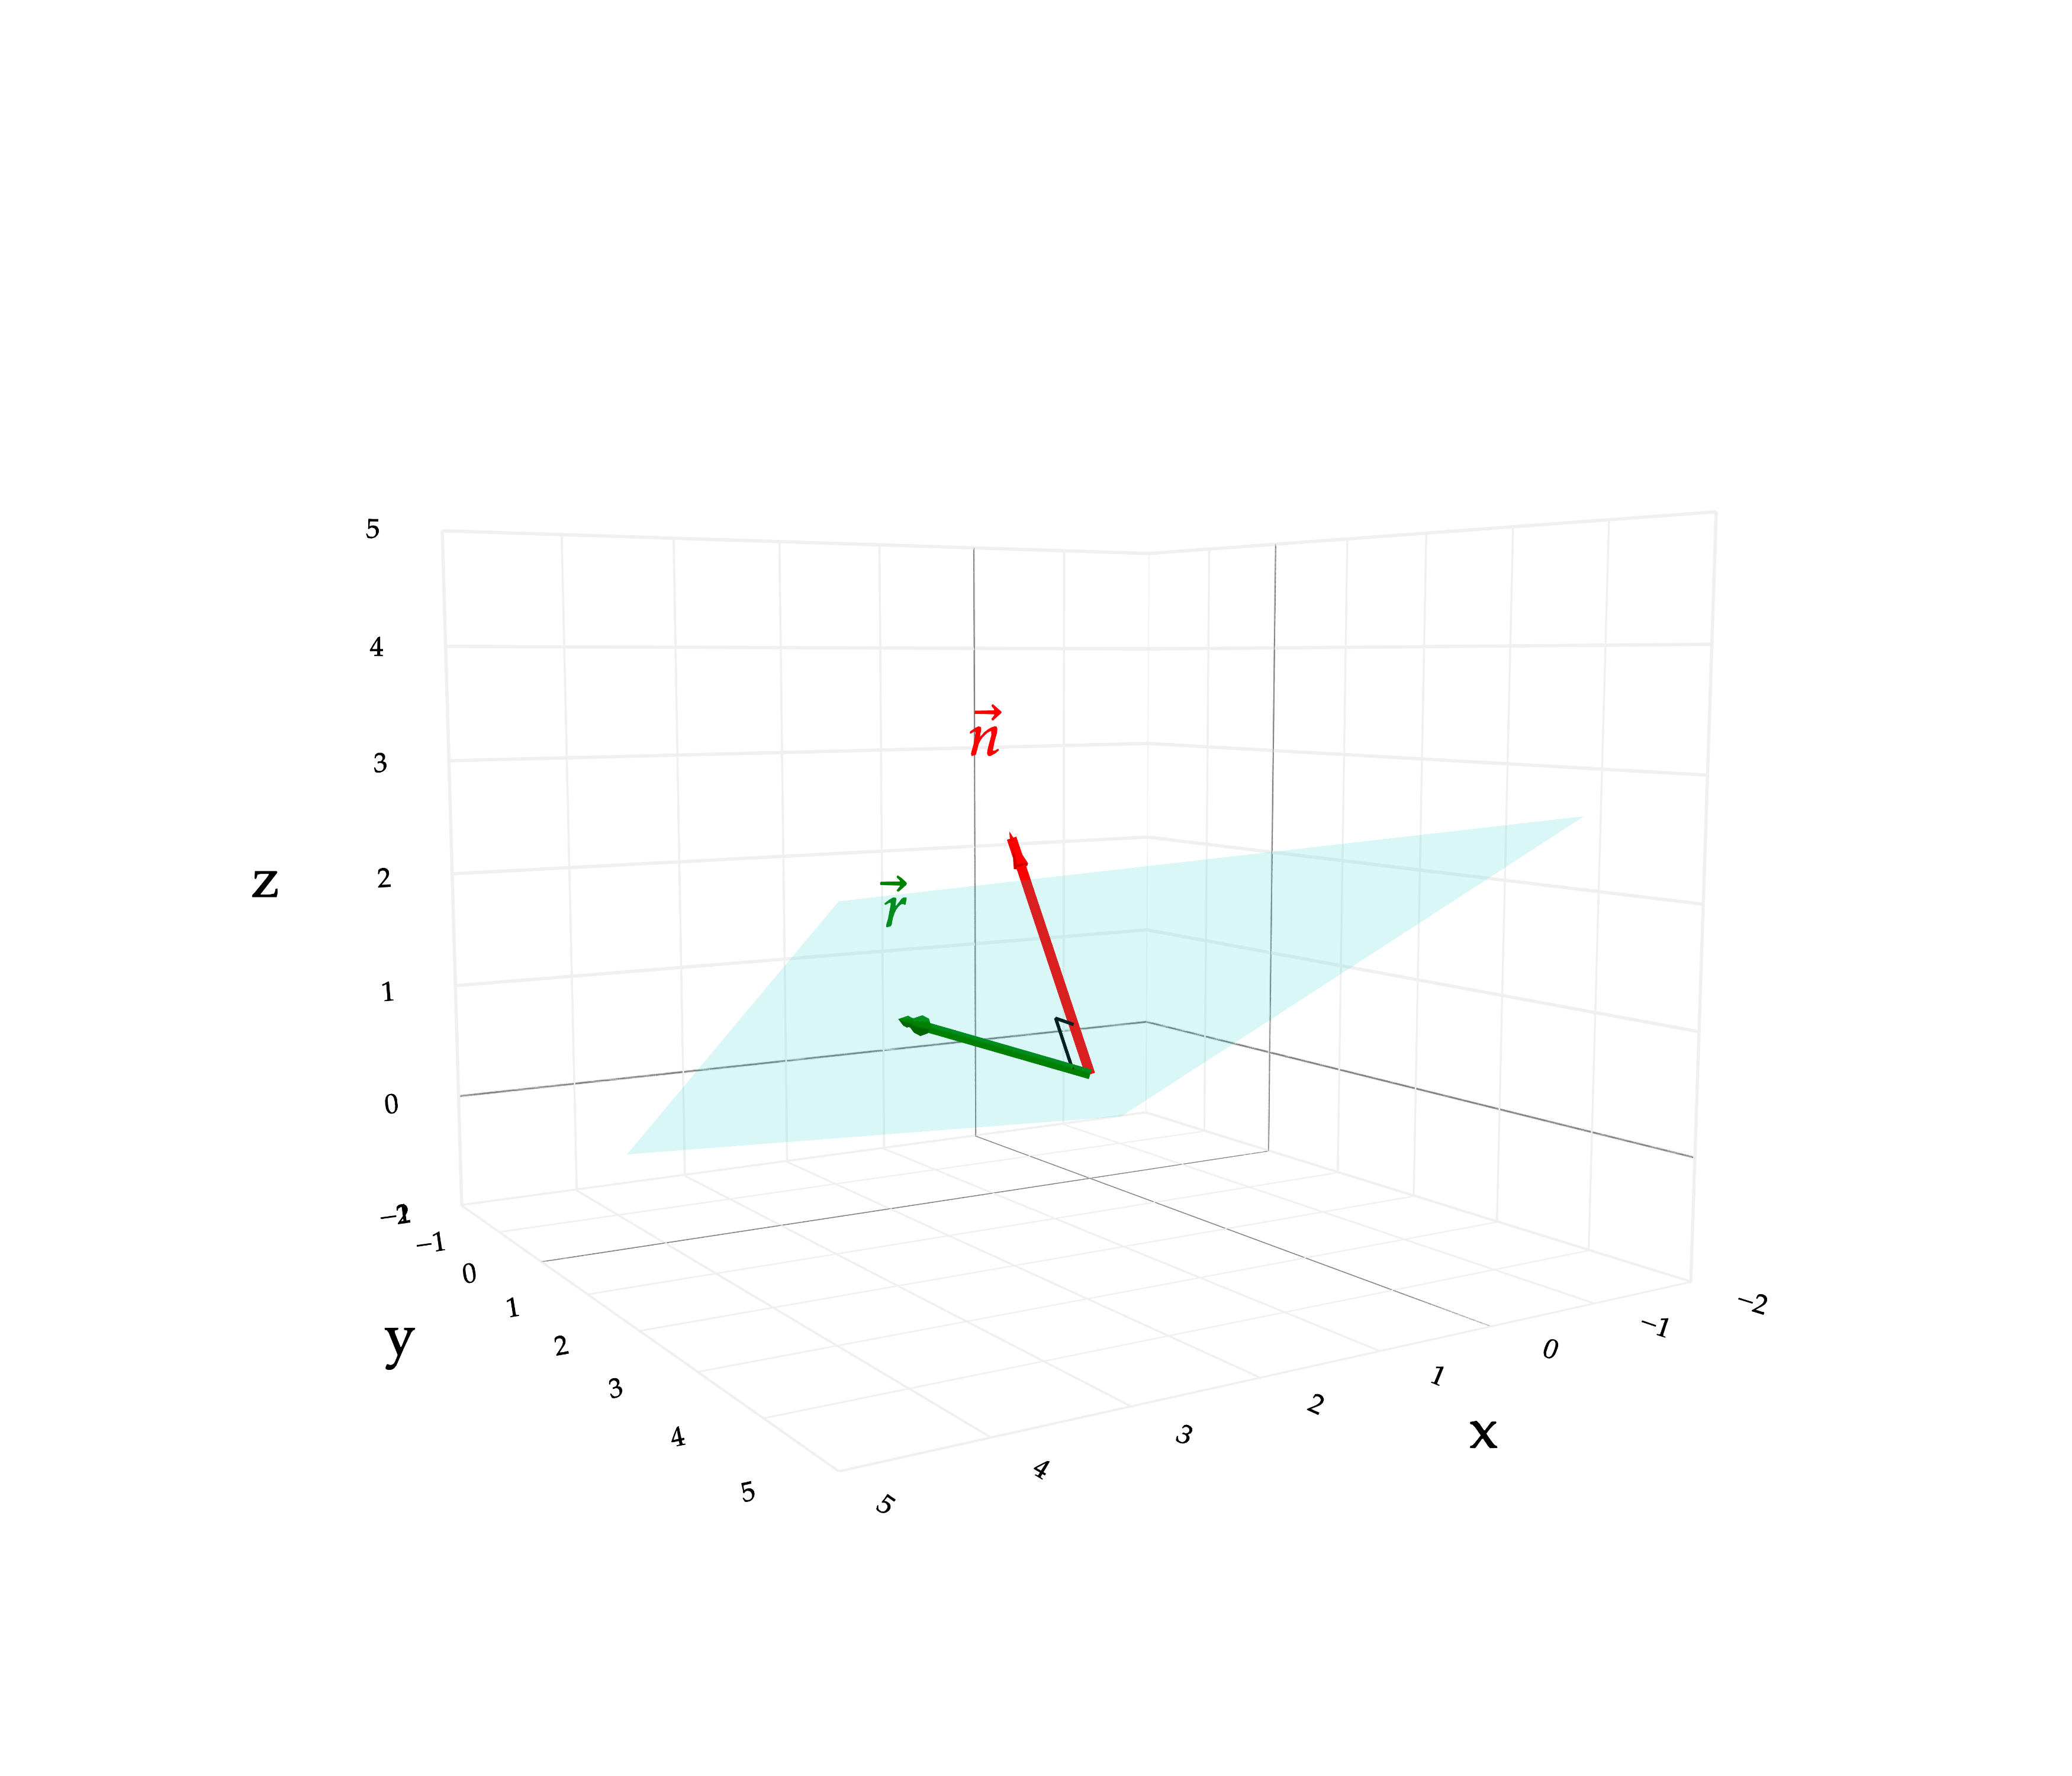

In [10]:
import plotly.io as pio
import plotly.graph_objects as go
import numpy as np

# Set default renderer to high-DPI static image
pio.renderers.default = "png"

# ---
from utils import plot_vectors_non_origin

# Define the coordinates using numpy arrays
O = np.array([0, 0, 0])
u = np.array([1.5, 0.5, 0.2])
v = np.array([0.2, 1.5, 0.8])

# Generate the shortened position vector r = 2u + v
r = 2*u + 1*v

# Calculate the orthogonal normal vector n using the cross product
n = np.cross(u, v)

# 1. REMOVE AUTOMATIC LABELS & FIX TUPLES
vectors = [
    ((tuple(O), tuple(r)), 'green', ''),                 
    ((tuple(O), tuple(n)), 'red', '')                
]

# Generate the base lines
fig = plot_vectors_non_origin(vectors, vdeltax=0, vdeltay=0, vdeltaz=0)

# 2. ADD THE SAME SPANNED PLANE (Semi-transparent)
c1 = -1*u - 1*v
c2 = 3*u - 1*v
c3 = 3*u + 4*v
c4 = -1*u + 4*v

fig.add_trace(go.Mesh3d(
    x=[c1[0], c2[0], c3[0], c4[0]],
    y=[c1[1], c2[1], c3[1], c4[1]],
    z=[c1[2], c2[2], c3[2], c4[2]],
    i=[0, 0], j=[1, 2], k=[2, 3],
    color='cyan',
    opacity=0.15,
    showscale=False,
    hoverinfo='skip'
))

# 3. ENHANCE ARROWHEADS WITH 3D CONES
def add_cone(fig, start, end, color):
    fig.add_trace(go.Cone(
        x=[end[0]], y=[end[1]], z=[end[2]],
        u=[end[0]-start[0]], v=[end[1]-start[1]], w=[end[2]-start[2]],
        sizemode="absolute", sizeref=0.3, anchor="tip",
        colorscale=[[0, color], [1, color]], showscale=False, hoverinfo='skip'
    ))

add_cone(fig, O, r, 'green')
add_cone(fig, O, n, 'red')

# 4. DRAW THE RIGHT-ANGLE SYMBOL AT THE ORIGIN
r_hat = r / np.linalg.norm(r)
n_hat = n / np.linalg.norm(n)
square_size = 0.5

# Calculate the corners of the right-angle marker
p1 = O + square_size * r_hat
p2 = p1 + square_size * n_hat
p3 = O + square_size * n_hat

fig.add_trace(go.Scatter3d(
    x=[p1[0], p2[0], p3[0]],
    y=[p1[1], p2[1], p3[1]],
    z=[p1[2], p2[2], p3[2]],
    mode='lines',
    line=dict(color='black', width=2),
    showlegend=False,
    hoverinfo='skip'
))

# 5. MANUAL LABEL POSITIONING
label_x = [r[0]+0.2, n[0]+0.1]
label_y = [r[1]+0.2, n[1]-0.3]
label_z = [r[2]+0.3, n[2]+0.2]
label_text = ['<i>r</i>\u20D7', '<i>n</i>\u20D7']
label_colors = ['green', 'red']

fig.add_trace(go.Scatter3d(
    x=label_x, y=label_y, z=label_z,
    mode='text', text=label_text,
    textfont=dict(color=label_colors, size=18),
    showlegend=False, hoverinfo='skip'
))

# Format the 3D layout
fig.update_layout(
    width=700, height=600,
    scene=dict(
        xaxis=dict(range=[-2, 5], dtick=1),
        yaxis=dict(range=[-2, 5], dtick=1),
        zaxis=dict(range=[-1, 5], dtick=1),
        aspectratio=dict(x=1, y=1, z=0.8)
    )
)

fig.show(scale=5)

Using the criterion for orthogonality, we can express the plane as the collection of vectors $\vec r$ satisfying:
$$ \vec n \cdot \vec r = 0.$$
This is called the **point-normal form** of the plane. 